<a href="https://colab.research.google.com/github/itsPratikHere/Linear-Regression-Model/blob/main/LinearRegressionModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

In [1]:
marks = pd.read_csv("student_marks_500.csv")
marks.head()

NameError: name 'pd' is not defined

In [ ]:
marks.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Student_ID  500 non-null    int64  
 1   Name        500 non-null    object 
 2   Maths       500 non-null    int64  
 3   Physics     500 non-null    int64  
 4   Chemistry   500 non-null    int64  
 5   English     500 non-null    int64  
 6   Computer    500 non-null    int64  
 7   Total       500 non-null    int64  
 8   Percentage  500 non-null    float64
 9   Grade       500 non-null    object 
dtypes: float64(1), int64(7), object(2)
memory usage: 39.2+ KB


In [ ]:
marks.describe()


,Student_ID,Maths,Physics,Chemistry,English,Computer,Total,Percentage
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,250.500000,68.356000,69.638000,70.518000,70.250000,69.068000,347.830000,69.566000
std,144.481833,17.719855,17.815098,17.553516,17.335759,17.829615,41.315555,8.263111
min,1.000000,40.000000,40.000000,40.000000,40.000000,40.000000,240.000000,48.000000
25%,125.750000,52.000000,54.000000,55.000000,56.000000,53.000000,319.750000,63.950000
50%,250.500000,67.000000,69.500000,70.000000,70.000000,70.000000,345.500000,69.100000
75%,375.250000,83.000000,85.000000,86.000000,86.000000,84.000000,377.000000,75.400000
max,500.000000,100.000000,100.000000,100.000000,100.000000,100.000000,471.000000,94.200000


In [ ]:
marks = marks.drop(["Name","Grade"],axis=1)

In [ ]:
marks.head()

,Student_ID,Maths,Physics,Chemistry,English,Computer,Total,Percentage
0,1,44,93,52,72,71,332,66.4
1,2,64,70,100,77,80,391,78.2
2,3,62,52,98,85,66,363,72.6
3,4,54,45,57,85,76,317,63.4
4,5,90,85,84,76,64,399,79.8


In [ ]:
marks.isnull().sum()

,0
Student_ID,0
Maths,0
Physics,0
Chemistry,0
English,0
Computer,0
Total,0
Percentage,0


**EDA**


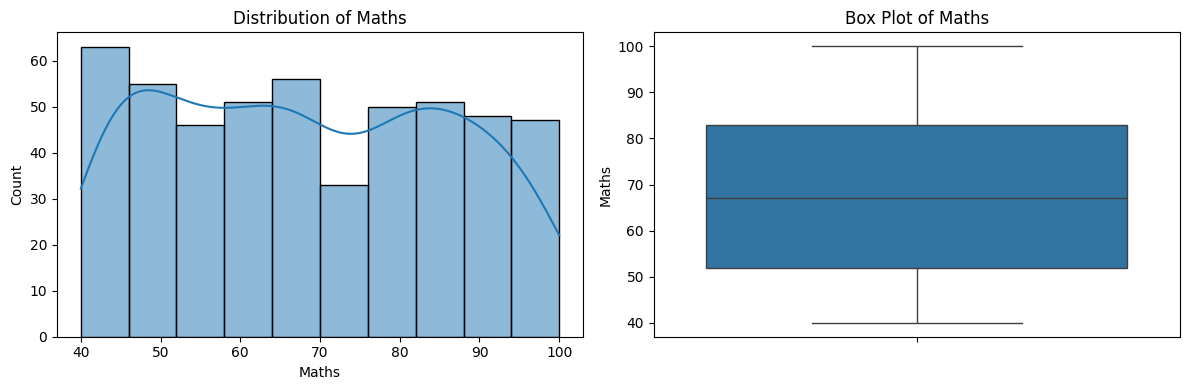

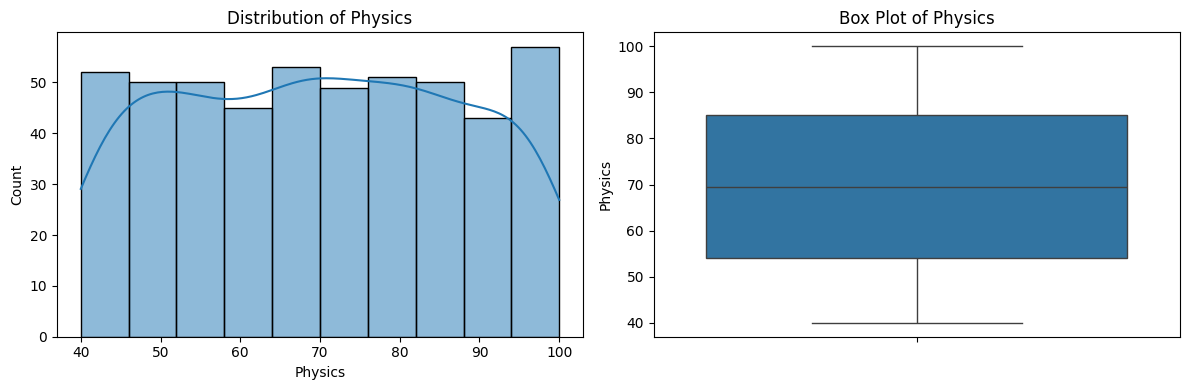

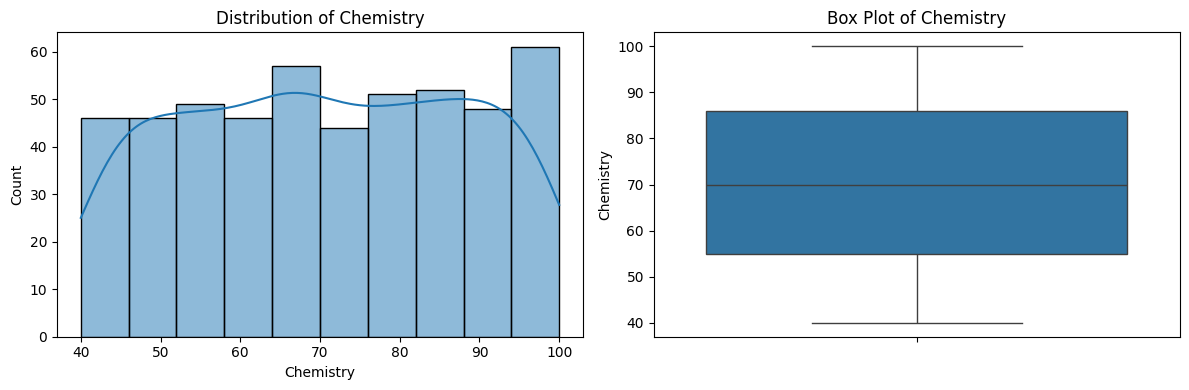

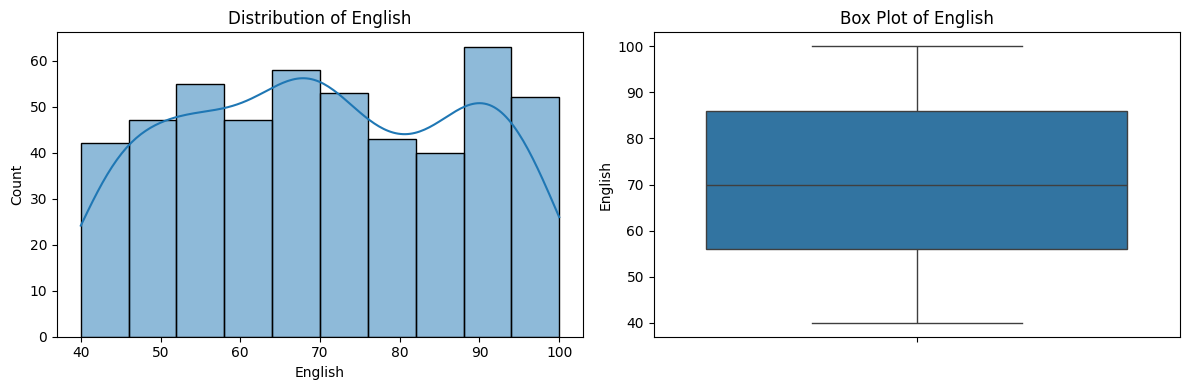

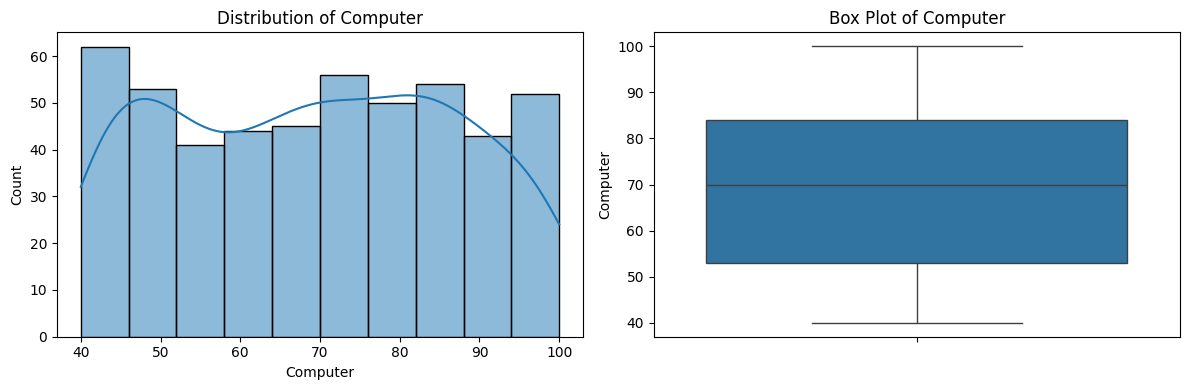

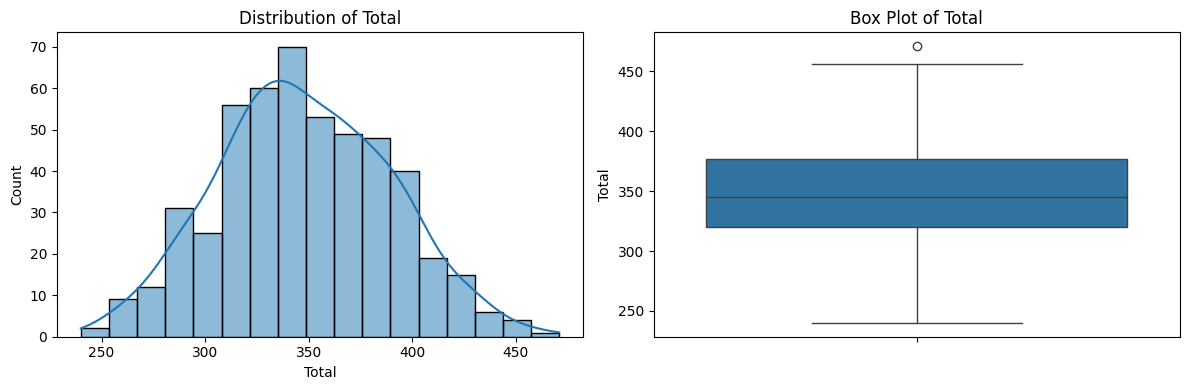

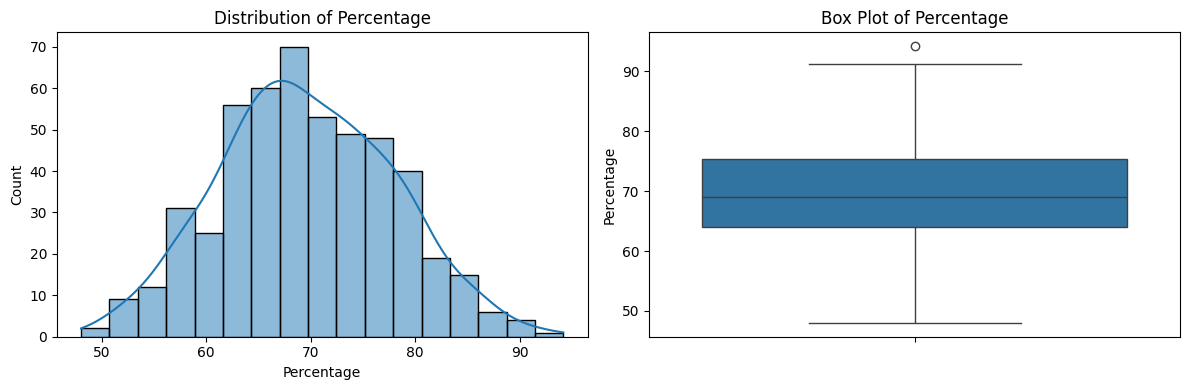

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

columns_to_visualize = ['Maths','Physics','Chemistry','English','Computer','Total','Percentage']

for column in columns_to_visualize:
    plt.figure(figsize=(12, 4))

    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(marks[column], kde=True)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)

    # Box Plot
    plt.subplot(1, 2, 2)
    sns.boxplot(marks[column])
    plt.title(f'Box Plot of {column}')
    plt.ylabel(column)

    plt.tight_layout()
    plt.show()

**DATA** **SPLIT**


In [ ]:
from sklearn.model_selection import train_test_split

#Features : The individual Subject Marks
X = marks[['Maths','Physics','Chemistry','English','Computer']]

#Traget
Y = marks['Total']

#Spliting the Dataset
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

#Verify the Split
print(f"Total rows: {len(marks)}")
print(f"Training rows:{len(X_train)}")
print(f"Testing rows: {len(X_test)}")



Total rows: 500
Training rows:400
Testing rows: 100


**MODEL TRAINING**

In [ ]:
from sklearn.linear_model import LinearRegression

#Initialize the model (Create the empty brain of the model)
model = LinearRegression()

#Training the Model using Training Dataset
#This is the place where model understands the relationship or mathematics btw the X and Y
model.fit(X_train,Y_train)

print(f"Model Training is completed {model}")

Model is Training is completed LinearRegression()


**MODEL PREDICTION**

In [ ]:
#Predict the result
Y_pred = model.predict(X_test)

print(len(Y_pred))

comparison = pd.DataFrame({"Actual":Y_test[:10],"Predicted":Y_pred[:10]})
print(comparison)

100
     Actual  Predicted
361     319      319.0
73      298      298.0
374     302      302.0
155     330      330.0
104     401      401.0
394     427      427.0
377     364      364.0
124     350      350.0
68      370      370.0
450     289      289.0


**ACCURACY CHECK**

In [ ]:
from sklearn.metrics import mean_absolute_error , r2_score

score = r2_score(Y_test,Y_pred)

mae = mean_absolute_error(Y_test,Y_pred)

print(f"R2 Score:{score*100:.2f}%")
print(f"Mean Absolute Error : {mae:.4f}")

R2 Score:100.00%
Mean Absolute Error : 0.0000


**PREDICTION FOR UNSEEN** **DATA**

In [ ]:
new_student_marks = [[95,88,75,85,99]]

prediction = model.predict(new_student_marks)

print(f"New Predicted Total Marks:{prediction[0]:.2f}")

New Predicted Total Marks:442.00


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
